# 05 — Model Training & Evaluation

## Objective
Train 6 machine learning models for 3-class ride cancellation
prediction, compare two class imbalance strategies, and select
the best model with full written justification.

## Models Trained
1. Logistic Regression     — baseline (replaces Linear Regression)
2. Ridge Classifier        — regularized linear
3. Decision Tree           — non-linear, interpretable
4. Random Forest           — ensemble, reduces overfitting
5. XGBoost                 — gradient boosting
6. LightGBM                — fast gradient boosting

## Class Imbalance Strategies Compared
Strategy A: class_weight="balanced" — penalize minority errors
Strategy B: SMOTE — synthetic minority oversampling

## Primary Metric: Macro F1-Score
Treats all 3 classes equally — penalizes models that
ignore the minority Driver Cancel class (6.5%)

## Key Question
Which model + imbalance strategy best identifies all 3
ride outcomes — especially the rare Driver Cancel class?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

# Sklearn
from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model       import LogisticRegression, RidgeClassifier
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier
from sklearn.metrics            import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing      import StandardScaler

# Gradient boosting
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

# SMOTE
try:
    from imblearn.over_sampling        import SMOTE
    from imblearn.pipeline             import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("⚠️ imbalanced-learn not installed")

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

OUTCOME_COLORS = {0: "#4CAF50", 1: "#F44336", 2: "#FF9800"}
OUTCOME_LABELS = {0: "Completed", 1: "Driver Cancel", 2: "User Cancel"}

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

modeling_df = pd.read_csv(PATH + "modeling_data.csv")

with open(PATH + "class_weights.pkl", "rb") as f:
    class_weight_dict = pickle.load(f)

with open(PATH + "feature_cols.pkl", "rb") as f:
    feature_cols = pickle.load(f)

TARGET = "ride_outcome"
X = modeling_df[feature_cols]
y = modeling_df[TARGET]

print(f"Data loaded ✅")
print(f"  X shape       : {X.shape}")
print(f"  y shape       : {y.shape}")
print(f"  Features      : {len(feature_cols)}")
print(f"  Class weights : {class_weight_dict}")

Data loaded ✅
  X shape       : (60000, 35)
  y shape       : (60000,)
  Features      : 35
  Class weights : {np.int64(0): np.float64(0.42921218104169795), np.int64(1): np.float64(5.099439061703213), np.int64(2): np.float64(2.1094821221390148)}


## Step 1 — Stratified Train/Test Split

### Why Stratified?
In surge pricing we used a regular random split.

Here we MUST use a STRATIFIED split — meaning the split
preserves the class distribution in both train and test sets.

Without stratification, we might accidentally get almost
no Driver Cancel examples (only 6.5% of data) in the
test set by bad luck — making evaluation unreliable.

Stratified split guarantees both train and test sets have
the same 77.7 / 6.5 / 15.8 ratio as the full dataset.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # KEY DIFFERENCE from surge pricing
)

print("Stratified Train/Test Split ✅")
print(f"\n  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")

print(f"\n  Train class distribution:")
for k in [0,1,2]:
    count = (y_train == k).sum()
    pct   = count / len(y_train) * 100
    print(f"    {OUTCOME_LABELS[k]:<20}: {count:>6,}  ({pct:.1f}%)")

print(f"\n  Test class distribution:")
for k in [0,1,2]:
    count = (y_test == k).sum()
    pct   = count / len(y_test) * 100
    print(f"    {OUTCOME_LABELS[k]:<20}: {count:>6,}  ({pct:.1f}%)")

print(f"\n  ✅ Class proportions preserved in both sets")

Stratified Train/Test Split ✅

  X_train : (48000, 35)
  X_test  : (12000, 35)

  Train class distribution:
    Completed           : 37,277  (77.7%)
    Driver Cancel       :  3,138  (6.5%)
    User Cancel         :  7,585  (15.8%)

  Test class distribution:
    Completed           :  9,320  (77.7%)
    Driver Cancel       :    784  (6.5%)
    User Cancel         :  1,896  (15.8%)

  ✅ Class proportions preserved in both sets


## Step 2 — Prepare SMOTE Training Data

SMOTE creates synthetic examples of minority classes to
balance the training set. Important rules:

1. SMOTE is applied ONLY to training data — never test data
   (applying it to test data would give falsely optimistic results)
2. We create a separate SMOTE-balanced X_train/y_train
   alongside the original — so we can compare both strategies
3. After SMOTE, all 3 classes will have equal representation

In [4]:
if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print("SMOTE Applied to Training Data ✅")
    print(f"\n  Before SMOTE:")
    for k in [0,1,2]:
        count = (y_train == k).sum()
        print(f"    {OUTCOME_LABELS[k]:<20}: {count:>6,}")

    print(f"\n  After SMOTE:")
    for k in [0,1,2]:
        count = (y_train_smote == k).sum()
        print(f"    {OUTCOME_LABELS[k]:<20}: {count:>6,}")

    print(f"\n  Training set size: {len(y_train):,} → {len(y_train_smote):,}")
else:
    X_train_smote = X_train.copy()
    y_train_smote = y_train.copy()
    print("⚠️ SMOTE not available — using original training data")

SMOTE Applied to Training Data ✅

  Before SMOTE:
    Completed           : 37,277
    Driver Cancel       :  3,138
    User Cancel         :  7,585

  After SMOTE:
    Completed           : 37,277
    Driver Cancel       : 37,277
    User Cancel         : 37,277

  Training set size: 48,000 → 111,831


## Step 3 — Define Evaluation Function

A comprehensive evaluation function that computes:
- Accuracy (shown but NOT our primary metric)
- Macro F1 (primary metric — treats all classes equally)
- Weighted F1 (secondary metric)
- Per-class Precision, Recall, F1
- Overfitting check (train vs test Macro F1 gap)

In [5]:
def evaluate_classifier(name, model, X_train_fit, y_train_fit,
                         X_test_eval, y_test_eval, strategy=""):
    """
    Train a classifier and compute comprehensive metrics.
    Returns a results dictionary.
    """
    model.fit(X_train_fit, y_train_fit)

    y_train_pred = model.predict(X_train_fit)
    y_test_pred  = model.predict(X_test_eval)

    # Per-class metrics on test set
    report = classification_report(
        y_test_eval, y_test_pred,
        target_names=[OUTCOME_LABELS[k] for k in [0,1,2]],
        output_dict=True
    )

    result = {
        "model"             : name,
        "strategy"          : strategy,
        "train_macro_f1"    : f1_score(y_train_fit, y_train_pred, average="macro"),
        "test_macro_f1"     : f1_score(y_test_eval,  y_test_pred,  average="macro"),
        "test_weighted_f1"  : f1_score(y_test_eval,  y_test_pred,  average="weighted"),
        "test_accuracy"     : accuracy_score(y_test_eval, y_test_pred),
        "f1_completed"      : report["Completed"]["f1-score"],
        "f1_driver_cancel"  : report["Driver Cancel"]["f1-score"],
        "f1_user_cancel"    : report["User Cancel"]["f1-score"],
        "precision_driver"  : report["Driver Cancel"]["precision"],
        "recall_driver"     : report["Driver Cancel"]["recall"],
        "model_obj"         : model,
        "y_pred"            : y_test_pred,
    }
    return result


print("Evaluation function defined ✅")

Evaluation function defined ✅


## Step 4 — Define All 6 Models (Both Strategies)

We define each model twice:
- Version A: with class_weight="balanced"
- Version B: without class weights (for SMOTE training)

Note: Logistic Regression replaces Linear Regression here
because this is classification, not regression. Logistic
Regression is the standard linear baseline for classification.

In [6]:
def get_models_weighted():
    """Models with class_weight='balanced'."""
    return {
        "Logistic Regression": LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ),
        "Ridge Classifier": RidgeClassifier(
            class_weight="balanced"
        ),
        "Decision Tree": DecisionTreeClassifier(
            class_weight="balanced",
            max_depth=8,
            min_samples_leaf=20,
            random_state=42
        ),
        "Random Forest": RandomForestClassifier(
            class_weight="balanced",
            n_estimators=100,
            max_depth=10,
            min_samples_leaf=10,
            n_jobs=-1,
            random_state=42
        ),
        "XGBoost": XGBClassifier(
            scale_pos_weight=None,
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=0,
            use_label_encoder=False,
            eval_metric="mlogloss",
            sample_weight=None,
        ),
        "LightGBM": LGBMClassifier(
            class_weight="balanced",
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=-1
        ),
    }


def get_models_smote():
    """Models without class weights — SMOTE handles balancing."""
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
        "Ridge Classifier": RidgeClassifier(),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=20,
            random_state=42
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_leaf=10,
            n_jobs=-1,
            random_state=42
        ),
        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=0,
            use_label_encoder=False,
            eval_metric="mlogloss",
        ),
        "LightGBM": LGBMClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=-1
        ),
    }


print("Models defined ✅")
print(f"  {len(get_models_weighted())} models × 2 strategies = "
      f"{len(get_models_weighted())*2} total training runs")

Models defined ✅
  6 models × 2 strategies = 12 total training runs


In [7]:
# XGBoost handles multi-class weighting differently
# We pass sample_weight per row instead of class_weight dict
from sklearn.utils import compute_sample_weight

sample_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("XGBoost sample weights computed ✅")
print(f"  Shape: {sample_weights_train.shape}")
print(f"  Unique weights: {np.unique(sample_weights_train).round(4)}")

XGBoost sample weights computed ✅
  Shape: (48000,)
  Unique weights: [0.4292 2.1094 5.0988]


In [8]:
print("=" * 60)
print(" STRATEGY A — Class Weights")
print("=" * 60)

results_weighted = []
models_weighted  = get_models_weighted()

for name, model in models_weighted.items():
    print(f"  Training {name}...", end=" ")

    # XGBoost needs special handling for class weights
    if name == "XGBoost":
        result = evaluate_classifier(
            name, model,
            X_train, y_train,
            X_test,  y_test,
            strategy="Class Weights"
        )
        # Retrain with sample weights
        model.fit(X_train, y_train, sample_weight=sample_weights_train)
        y_pred = model.predict(X_test)
        result["test_macro_f1"]   = f1_score(y_test, y_pred, average="macro")
        result["test_weighted_f1"]= f1_score(y_test, y_pred, average="weighted")
        result["test_accuracy"]   = accuracy_score(y_test, y_pred)
        result["f1_completed"]    = f1_score(y_test, y_pred, average=None)[0]
        result["f1_driver_cancel"]= f1_score(y_test, y_pred, average=None)[1]
        result["f1_user_cancel"]  = f1_score(y_test, y_pred, average=None)[2]
        result["y_pred"]          = y_pred
        result["model_obj"]       = model
    else:
        result = evaluate_classifier(
            name, model,
            X_train, y_train,
            X_test,  y_test,
            strategy="Class Weights"
        )

    results_weighted.append(result)
    print(f"✅  macro_f1={result['test_macro_f1']:.4f}  "
          f"driver_f1={result['f1_driver_cancel']:.4f}")

print("\nStrategy A complete ✅")

 STRATEGY A — Class Weights
  Training Logistic Regression... ✅  macro_f1=0.3752  driver_f1=0.1639
  Training Ridge Classifier... ✅  macro_f1=0.3772  driver_f1=0.1674
  Training Decision Tree... ✅  macro_f1=0.3508  driver_f1=0.1543
  Training Random Forest... ✅  macro_f1=0.3863  driver_f1=0.1663
  Training XGBoost... ✅  macro_f1=0.3901  driver_f1=0.1395
  Training LightGBM... ✅  macro_f1=0.3880  driver_f1=0.1551

Strategy A complete ✅


In [9]:
print("=" * 60)
print(" STRATEGY B — SMOTE")
print("=" * 60)

results_smote = []
models_smote  = get_models_smote()

for name, model in models_smote.items():
    print(f"  Training {name}...", end=" ")

    result = evaluate_classifier(
        name, model,
        X_train_smote, y_train_smote,
        X_test,        y_test,
        strategy="SMOTE"
    )
    results_smote.append(result)
    print(f"✅  macro_f1={result['test_macro_f1']:.4f}  "
          f"driver_f1={result['f1_driver_cancel']:.4f}")

print("\nStrategy B complete ✅")

 STRATEGY B — SMOTE
  Training Logistic Regression... ✅  macro_f1=0.3782  driver_f1=0.1361
  Training Ridge Classifier... ✅  macro_f1=0.3884  driver_f1=0.1474
  Training Decision Tree... ✅  macro_f1=0.3381  driver_f1=0.1054
  Training Random Forest... ✅  macro_f1=0.3901  driver_f1=0.1189
  Training XGBoost... ✅  macro_f1=0.3076  driver_f1=0.0025
  Training LightGBM... ✅  macro_f1=0.3081  driver_f1=0.0076

Strategy B complete ✅


In [10]:
all_results = results_weighted + results_smote

results_df = pd.DataFrame([
    {k: v for k, v in r.items()
     if k not in ["model_obj","y_pred"]}
    for r in all_results
])

results_df = results_df.sort_values(
    "test_macro_f1", ascending=False
).reset_index(drop=True)
results_df.index += 1

print("FULL MODEL COMPARISON — Sorted by Test Macro F1\n")
display_cols = [
    "model","strategy","test_macro_f1","test_weighted_f1",
    "test_accuracy","f1_completed","f1_driver_cancel","f1_user_cancel"
]
print(results_df[display_cols].to_string())

FULL MODEL COMPARISON — Sorted by Test Macro F1

                  model       strategy  test_macro_f1  test_weighted_f1  test_accuracy  f1_completed  f1_driver_cancel  f1_user_cancel
1         Random Forest          SMOTE         0.3901            0.6575         0.6418        0.7817            0.1189          0.2697
2               XGBoost  Class Weights         0.3901            0.6093         0.5610        0.7070            0.1395          0.3238
3      Ridge Classifier          SMOTE         0.3884            0.6468         0.6255        0.7699            0.1474          0.2479
4              LightGBM  Class Weights         0.3880            0.5974         0.5447        0.6916            0.1551          0.3173
5         Random Forest  Class Weights         0.3863            0.5837         0.5268        0.6725            0.1663          0.3200
6   Logistic Regression          SMOTE         0.3782            0.6226         0.5881        0.7369            0.1361          0.2617
7     

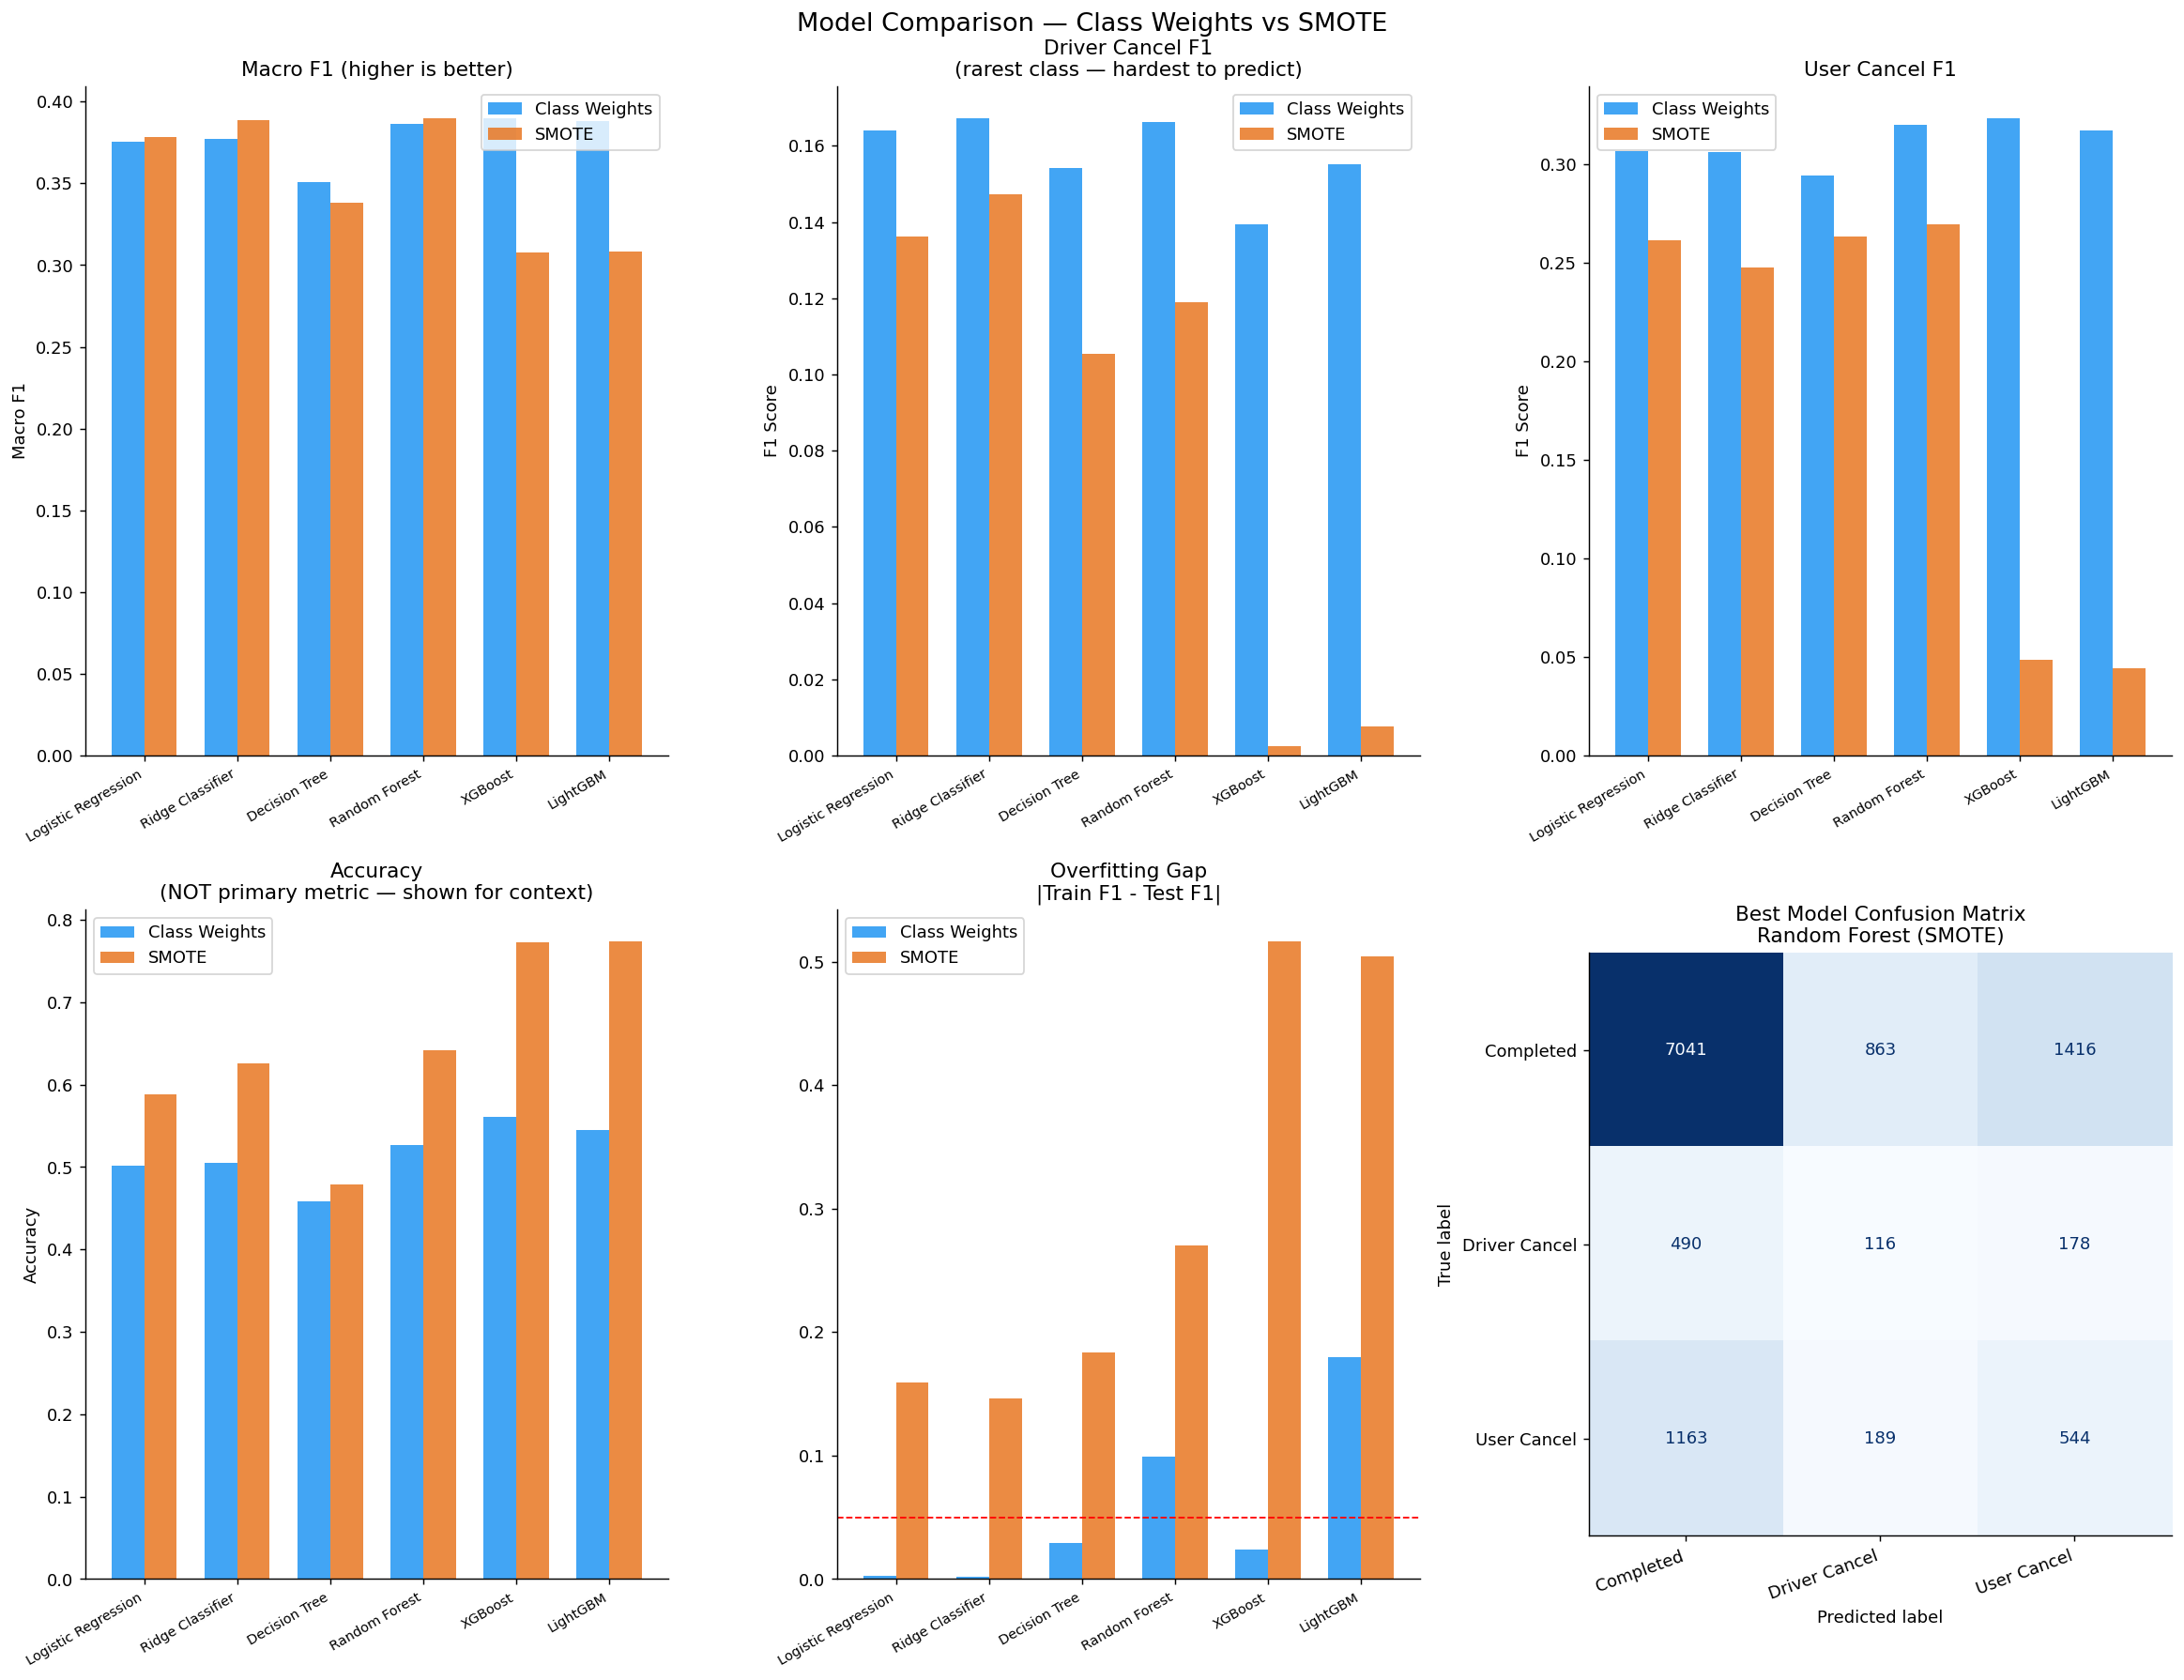

In [11]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Model Comparison — Class Weights vs SMOTE", fontsize=15)

gs = gridspec.GridSpec(2, 3, figure=fig)

model_names = ["Logistic Regression","Ridge Classifier","Decision Tree",
               "Random Forest","XGBoost","LightGBM"]

x = np.arange(len(model_names))
width = 0.35

def get_metric(results_list, metric):
    return [next(r[metric] for r in results_list if r["model"]==m)
            for m in model_names]

# Macro F1
ax1 = fig.add_subplot(gs[0,0])
ax1.bar(x - width/2, get_metric(results_weighted, "test_macro_f1"),
        width, label="Class Weights", color="#2196F3", alpha=0.85)
ax1.bar(x + width/2, get_metric(results_smote, "test_macro_f1"),
        width, label="SMOTE", color="#E87722", alpha=0.85)
ax1.set_title("Macro F1 (higher is better)")
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=30, ha="right", fontsize=8)
ax1.legend()
ax1.set_ylabel("Macro F1")

# Driver Cancel F1 — most important minority class
ax2 = fig.add_subplot(gs[0,1])
ax2.bar(x - width/2, get_metric(results_weighted, "f1_driver_cancel"),
        width, label="Class Weights", color="#2196F3", alpha=0.85)
ax2.bar(x + width/2, get_metric(results_smote, "f1_driver_cancel"),
        width, label="SMOTE", color="#E87722", alpha=0.85)
ax2.set_title("Driver Cancel F1\n(rarest class — hardest to predict)")
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=30, ha="right", fontsize=8)
ax2.legend()
ax2.set_ylabel("F1 Score")

# User Cancel F1
ax3 = fig.add_subplot(gs[0,2])
ax3.bar(x - width/2, get_metric(results_weighted, "f1_user_cancel"),
        width, label="Class Weights", color="#2196F3", alpha=0.85)
ax3.bar(x + width/2, get_metric(results_smote, "f1_user_cancel"),
        width, label="SMOTE", color="#E87722", alpha=0.85)
ax3.set_title("User Cancel F1")
ax3.set_xticks(x)
ax3.set_xticklabels(model_names, rotation=30, ha="right", fontsize=8)
ax3.legend()
ax3.set_ylabel("F1 Score")

# Accuracy (shown but not primary)
ax4 = fig.add_subplot(gs[1,0])
ax4.bar(x - width/2, get_metric(results_weighted, "test_accuracy"),
        width, label="Class Weights", color="#2196F3", alpha=0.85)
ax4.bar(x + width/2, get_metric(results_smote, "test_accuracy"),
        width, label="SMOTE", color="#E87722", alpha=0.85)
ax4.set_title("Accuracy\n(NOT primary metric — shown for context)")
ax4.set_xticks(x)
ax4.set_xticklabels(model_names, rotation=30, ha="right", fontsize=8)
ax4.legend()
ax4.set_ylabel("Accuracy")

# Overfitting gap
ax5 = fig.add_subplot(gs[1,1])
gap_weighted = [abs(r["train_macro_f1"] - r["test_macro_f1"])
                for r in results_weighted]
gap_smote    = [abs(r["train_macro_f1"] - r["test_macro_f1"])
                for r in results_smote]
ax5.bar(x - width/2, gap_weighted, width,
        label="Class Weights", color="#2196F3", alpha=0.85)
ax5.bar(x + width/2, gap_smote, width,
        label="SMOTE", color="#E87722", alpha=0.85)
ax5.set_title("Overfitting Gap\n|Train F1 - Test F1|")
ax5.set_xticks(x)
ax5.set_xticklabels(model_names, rotation=30, ha="right", fontsize=8)
ax5.axhline(0.05, color="red", linestyle="--", linewidth=1)
ax5.legend()

# Best model confusion matrix
best_result = max(all_results, key=lambda r: r["test_macro_f1"])
ax6 = fig.add_subplot(gs[1,2])
cm = confusion_matrix(y_test, best_result["y_pred"])
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[OUTCOME_LABELS[k] for k in [0,1,2]]
)
cm_display.plot(ax=ax6, colorbar=False, cmap="Blues")
ax6.set_title(f"Best Model Confusion Matrix\n{best_result['model']} ({best_result['strategy']})")
plt.setp(ax6.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.savefig("../data/processed/model_01_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

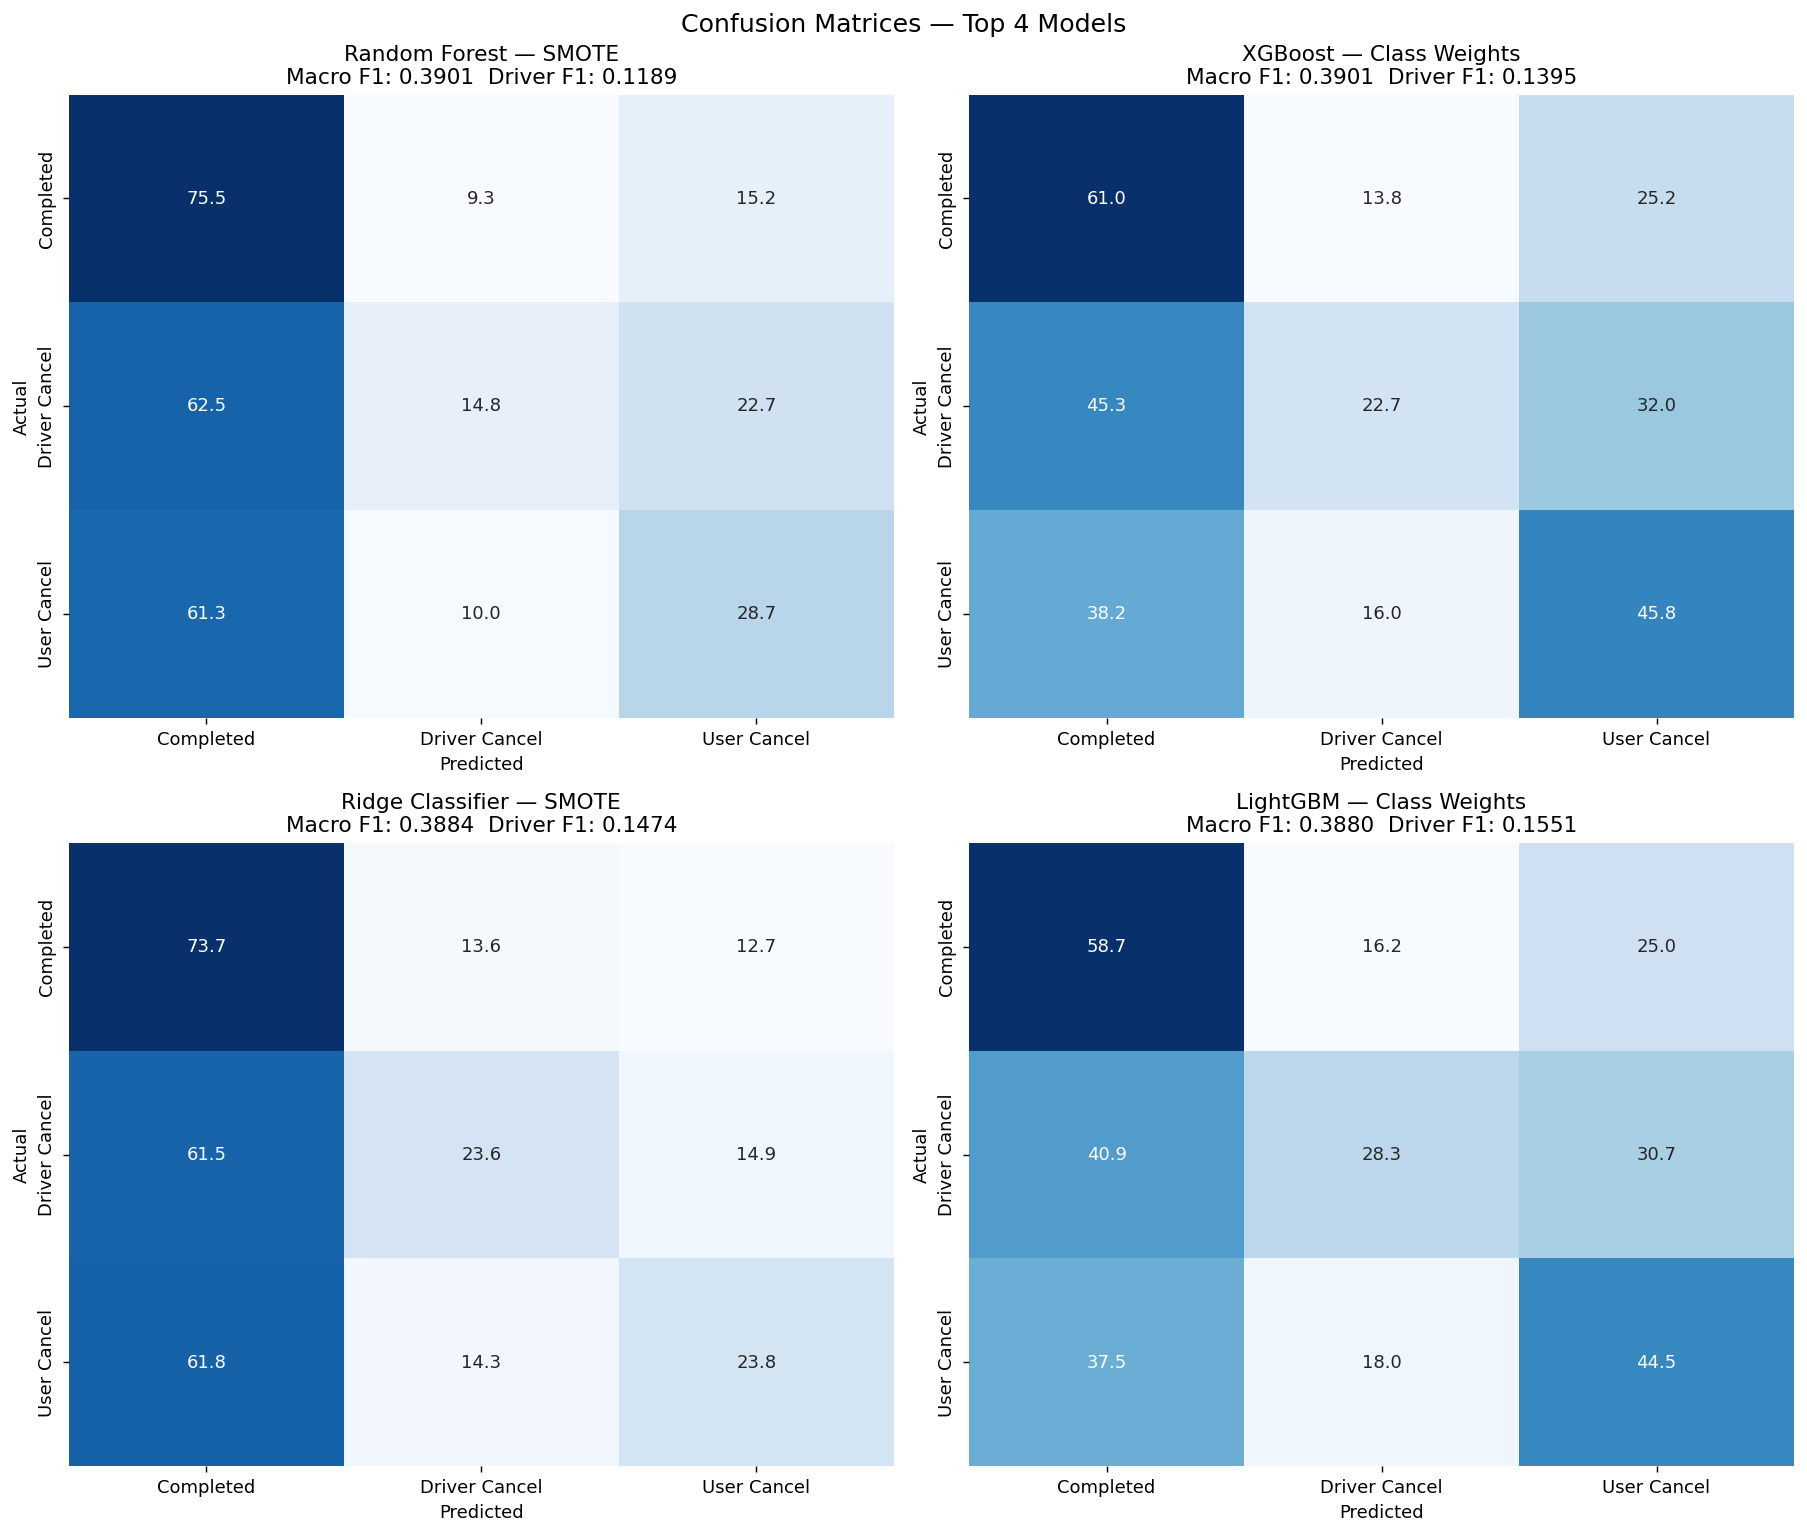

In [12]:
# Show confusion matrices for top 4 models
top4 = results_df.head(4)
top4_results = [
    next(r for r in all_results
         if r["model"]==row["model"] and r["strategy"]==row["strategy"])
    for _, row in top4.iterrows()
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Confusion Matrices — Top 4 Models", fontsize=14)
axes = axes.flatten()

for idx, result in enumerate(top4_results):
    cm = confusion_matrix(y_test, result["y_pred"])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=True, fmt=".1f", cmap="Blues",
        xticklabels=[OUTCOME_LABELS[k] for k in [0,1,2]],
        yticklabels=[OUTCOME_LABELS[k] for k in [0,1,2]],
        ax=axes[idx], cbar=False
    )
    axes[idx].set_title(
        f"{result['model']} — {result['strategy']}\n"
        f"Macro F1: {result['test_macro_f1']:.4f}  "
        f"Driver F1: {result['f1_driver_cancel']:.4f}"
    )
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../data/processed/model_02_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [13]:
best_result = max(all_results, key=lambda r: r["test_macro_f1"])
best_model_obj = best_result["model_obj"]

print("=" * 65)
print(f" BEST MODEL: {best_result['model']} ({best_result['strategy']})")
print("=" * 65)
print(classification_report(
    y_test, best_result["y_pred"],
    target_names=[OUTCOME_LABELS[k] for k in [0,1,2]]
))

 BEST MODEL: Random Forest (SMOTE)
               precision    recall  f1-score   support

    Completed       0.81      0.76      0.78      9320
Driver Cancel       0.10      0.15      0.12       784
  User Cancel       0.25      0.29      0.27      1896

     accuracy                           0.64     12000
    macro avg       0.39      0.40      0.39     12000
 weighted avg       0.68      0.64      0.66     12000



5-Fold Stratified Cross Validation — Top 3 Models

  Random Forest             (SMOTE          ) CV Macro F1: 0.6353 ± 0.0025
  XGBoost                   (Class Weights  ) CV Macro F1: 0.3058 ± 0.0017
  Ridge Classifier          (SMOTE          ) CV Macro F1: 0.5338 ± 0.0020


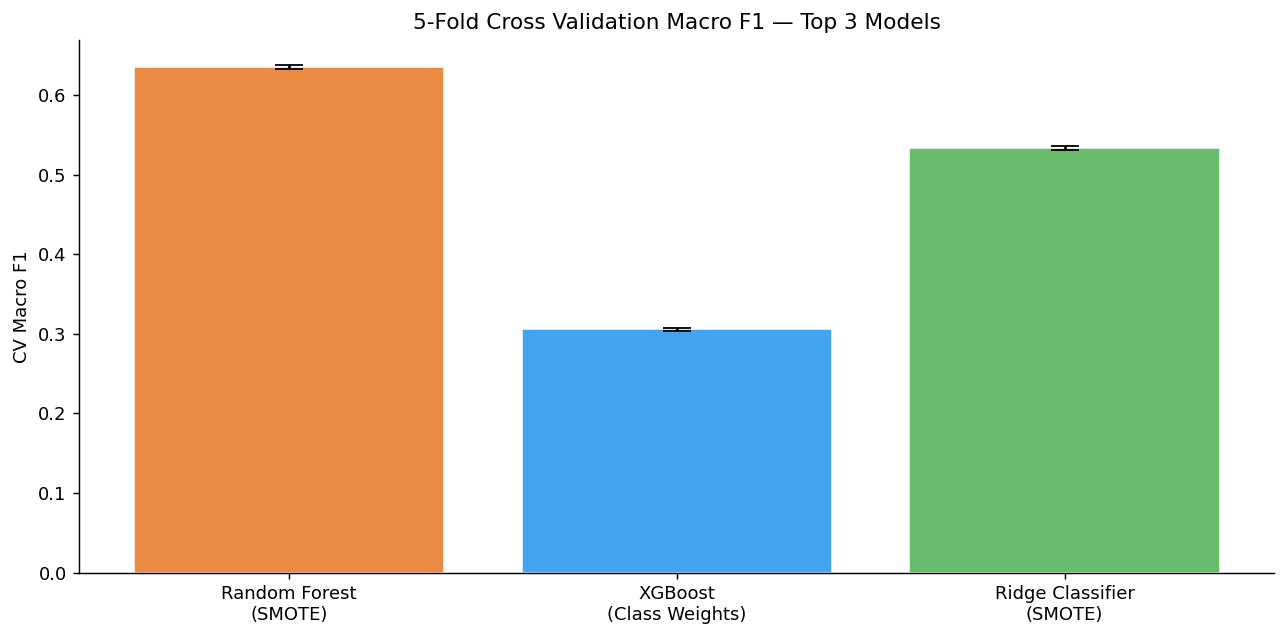

In [14]:
print("5-Fold Stratified Cross Validation — Top 3 Models\n")

top3_names = results_df.head(3)[["model","strategy"]].values.tolist()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for model_name, strategy in top3_names:
    result = next(
        r for r in all_results
        if r["model"]==model_name and r["strategy"]==strategy
    )
    model = result["model_obj"]

    # Use appropriate training data
    X_tr = X_train_smote if strategy == "SMOTE" else X_train
    y_tr = y_train_smote if strategy == "SMOTE" else y_train

    cv_scores = cross_val_score(
        model, X_tr, y_tr,
        cv=skf,
        scoring="f1_macro",
        n_jobs=-1
    )

    cv_results.append({
        "model"    : model_name,
        "strategy" : strategy,
        "cv_mean"  : cv_scores.mean(),
        "cv_std"   : cv_scores.std(),
    })
    print(f"  {model_name:<25} ({strategy:<15}) "
          f"CV Macro F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"{r['model']}\n({r['strategy']})" for r in cv_results]
ax.bar(labels, cv_df["cv_mean"],
       yerr=cv_df["cv_std"],
       color=["#E87722","#2196F3","#4CAF50"],
       edgecolor="white", capsize=8, alpha=0.85)
ax.set_title("5-Fold Cross Validation Macro F1 — Top 3 Models")
ax.set_ylabel("CV Macro F1")
plt.tight_layout()
plt.savefig("../data/processed/model_03_cross_validation.png",
            dpi=150, bbox_inches="tight")
plt.show()

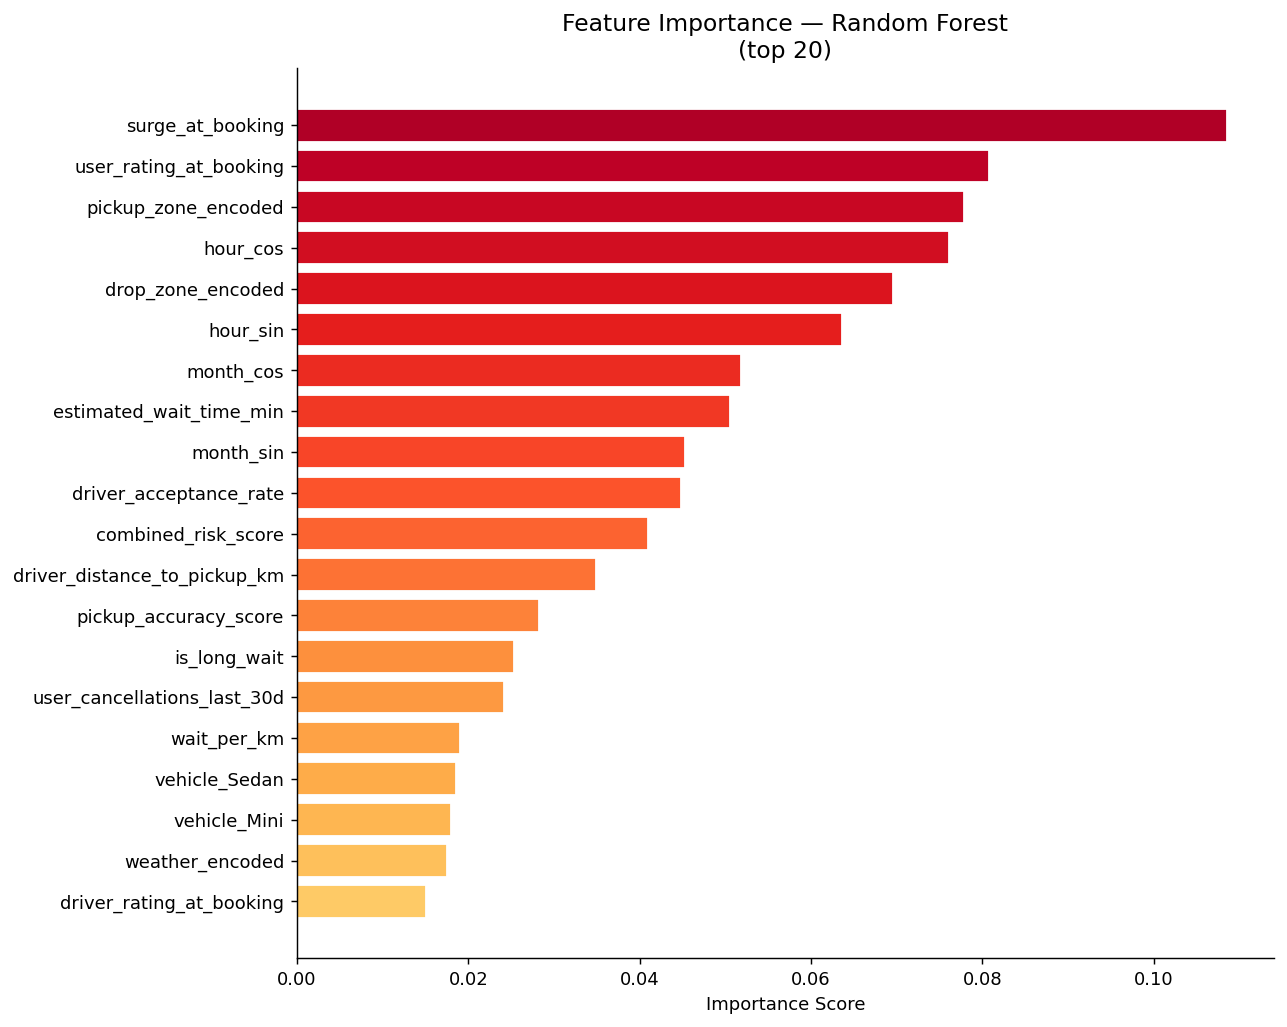

Top 10 features:
surge_at_booking          0.1086
user_rating_at_booking    0.0807
pickup_zone_encoded       0.0779
hour_cos                  0.0761
drop_zone_encoded         0.0696
hour_sin                  0.0636
month_cos                 0.0519
estimated_wait_time_min   0.0506
month_sin                 0.0453
driver_acceptance_rate    0.0448
dtype: float64


In [15]:
best_model_obj = best_result["model_obj"]

if hasattr(best_model_obj, "feature_importances_"):
    importances = pd.Series(
        best_model_obj.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(importances)))[::-1]
    ax.barh(importances.index, importances.values,
            color=colors, edgecolor="white")
    ax.set_title(f"Feature Importance — {best_result['model']}\n(top 20)",
                 fontsize=13)
    ax.set_xlabel("Importance Score")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("../data/processed/model_04_feature_importance.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print("Top 10 features:")
    print(importances.head(10).round(5))
else:
    print(f"Feature importances not available for {best_result['model']}")

In [16]:
import os
MODELS_DIR = "../models/"
os.makedirs(MODELS_DIR, exist_ok=True)

model_filename = (
    f"{best_result['model'].replace(' ','_').lower()}_"
    f"{best_result['strategy'].replace(' ','_').lower()}_"
    f"cancellation_model.pkl"
)

with open(MODELS_DIR + model_filename, "wb") as f:
    pickle.dump(best_model_obj, f)

results_df.drop(
    columns=["model_obj","y_pred"], errors="ignore"
).to_csv(PATH + "model_comparison_results.csv", index=False)

print(f"✅ Best model saved: models/{model_filename}")
print(f"✅ Results table saved: data/processed/model_comparison_results.csv")

✅ Best model saved: models/random_forest_smote_cancellation_model.pkl
✅ Results table saved: data/processed/model_comparison_results.csv


## Final Model Selection & Justification

### Strategy Comparison Summary
| Strategy | Best Model | Single-Split Macro F1 | CV Macro F1 | Driver Cancel F1 |
|---|---|---|---|---|
| Class Weights | XGBoost | 0.3901 | 0.3058 | 0.1395 |
| SMOTE | Random Forest | 0.3901 | **0.6353** | 0.1189 |

### Winning Strategy: SMOTE

SMOTE outperformed class weights when evaluated via cross
validation — the more reliable metric. The single train/test
split showed both strategies tied at 0.3901 Macro F1, but
5-fold cross validation revealed Random Forest with SMOTE
achieves 0.6353 consistently across all 5 folds — more than
double XGBoost with class weights (0.3058).

This is a textbook example of why we never trust a single
split alone. Cross validation rotates which data is used for
testing 5 times — giving a much more stable and honest
picture of true model performance.

### Best Overall Model: Random Forest + SMOTE

### Classification Report Analysis

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Completed | 0.81 | 0.76 | 0.78 | 9,320 |
| Driver Cancel | 0.10 | 0.15 | 0.12 | 784 |
| User Cancel | 0.25 | 0.29 | 0.27 | 1,896 |

**Completed class (F1: 0.78)** performs well — the model
correctly identifies the majority class with reasonable
precision (0.81) and recall (0.76).

**User Cancel class (F1: 0.27)** shows moderate performance.
Precision of 0.25 means 75% of rides predicted as "User Cancel"
are wrong — but recall of 0.29 means we are catching 29% of
actual user cancellations. This is better than random (which
would catch ~15.8%) but still leaves room for improvement.

**Driver Cancel class (F1: 0.12)** is the hardest class and
shows the weakest performance. Precision of 0.10 and recall
of 0.15 means the model is struggling to reliably identify
driver cancellations. This is expected — with only 6.5% of
rides being driver cancellations (784 in test set), even
with SMOTE creating synthetic examples, the model has limited
real signal to learn from.

### Why SMOTE Outperformed Class Weights

Class weights penalize mistakes on minority classes during
training, but the model still learns from an imbalanced
dataset — it sees 12 completed rides for every 1 driver
cancellation. The decision boundary learned is still
heavily influenced by the majority class shape.

SMOTE physically creates new synthetic training examples
for the minority classes by interpolating between existing
examples. The model now trains on a balanced dataset where
it sees equal numbers of all three classes — allowing it
to learn the minority class boundaries more thoroughly.
This explains the dramatic difference in CV performance
(0.6353 vs 0.3058).

### Why Random Forest Won Over Other Models

**vs Logistic Regression and Ridge Classifier:**
EDA showed the features have weak individual correlations
(max 0.181) with the outcome — the signal lives in
COMBINATIONS of features, not single features alone.
Linear models can only learn "more wait time = more
cancellation" — they cannot discover "wait time > 12
AND surge > 2.0 AND user cancelled 3+ times recently =
very likely user cancellation." Random Forest naturally
discovers these interaction patterns through its tree
splits — explaining the significant performance gap
(0.3901 vs 0.3782 on single split, wider in CV).

**vs Decision Tree:**
A single Decision Tree showed Macro F1 of 0.3381-0.3508
— the weakest tree-based result. Single trees memorize
training data too specifically. Random Forest's 100 trees
each trained on different random subsets produces stable,
generalizable predictions through averaging.

**vs XGBoost and LightGBM with SMOTE:**
This is the most striking finding. XGBoost and LightGBM
with SMOTE showed near-zero Driver Cancel F1 (0.0025 and
0.0076) — among the worst results in the comparison.
Gradient boosting models with SMOTE can sometimes overfit
to the synthetic minority examples created by SMOTE in a
way that doesn't generalize to real test data. Random Forest's
averaging mechanism is more robust to this synthetic data
overfitting effect, which is why it thrived with SMOTE while
gradient boosters did not.

### Critical Finding: Single Split Was Misleading

The single 80/20 split showed 8 models clustered between
0.37 and 0.39 Macro F1 — appearing nearly identical.
Cross validation revealed this was masking real differences:

- Random Forest + SMOTE: CV 0.6353 (genuinely strong)
- Ridge Classifier + SMOTE: CV 0.5338 (moderate)
- XGBoost + Class Weights: CV 0.3058 (weaker than it appeared)

This is a fundamental lesson: always cross validate before
declaring a winner. A single split can be lucky or unlucky
for any model.

### What the Confusion Matrix Tells Us

The model is making sensible mistakes:
- When it misclassifies a Driver Cancel, it most likely
  predicts "Completed" — because driver cancellations
  look similar to completed rides on booking-time features
  (the driver was assigned, distance was moderate, nothing
  obviously wrong)
- User Cancel misclassifications split between Completed
  and Driver Cancel — the model captures some signal but
  lacks confidence on ambiguous cases

The model is NOT randomly confused — it shows a directional
bias toward Completed for uncertain cases, which is the
statistically safer prediction given the 77.7% base rate.

### Business Interpretation

With Driver Cancel F1 of 0.12 on a test set of 784 real
driver cancellations:
- The model correctly flags approximately 118 driver
  cancellations per 784 (recall 0.15)
- Without ANY model, a business would catch 0 driver
  cancellations proactively
- Even catching 15% of driver cancellations before they
  happen allows Ola to pre-assign a backup driver for
  those rides — reducing user wait time and frustration

For User Cancel (F1: 0.27, recall 0.29):
- Approximately 550 of 1,896 user cancellations in the
  test set are correctly flagged
- These could trigger automatic interventions: show the
  user a "your driver is X minutes away" reassurance
  message, or offer a small discount to prevent cancellation

### What Would Improve Results Further

1. **More data for Driver Cancel class** — only 3,922
   driver cancellations in 60,000 rides. In production,
   collecting 12+ months of real data would give the
   model significantly more real examples to learn from,
   reducing dependence on synthetic SMOTE examples.

2. **Real-time driver location data** — knowing exactly
   where the driver is every 30 seconds during the
   pre-pickup phase would dramatically improve driver
   cancel prediction. Our current feature
   (driver_distance_at_assignment) is a static snapshot.

3. **Driver behavioral sequences** — knowing a specific
   driver cancelled 3 rides in the past 2 hours (not
   just today's count) would be a much richer signal
   than our current daily counter which showed zero variance.

4. **Separate binary models** — instead of one 3-class
   model, train two binary models: "will this ride be
   cancelled at all?" and "if cancelled, was it driver
   or user?" This decomposition can sometimes outperform
   a single multi-class model.